# Load cytof data

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotat

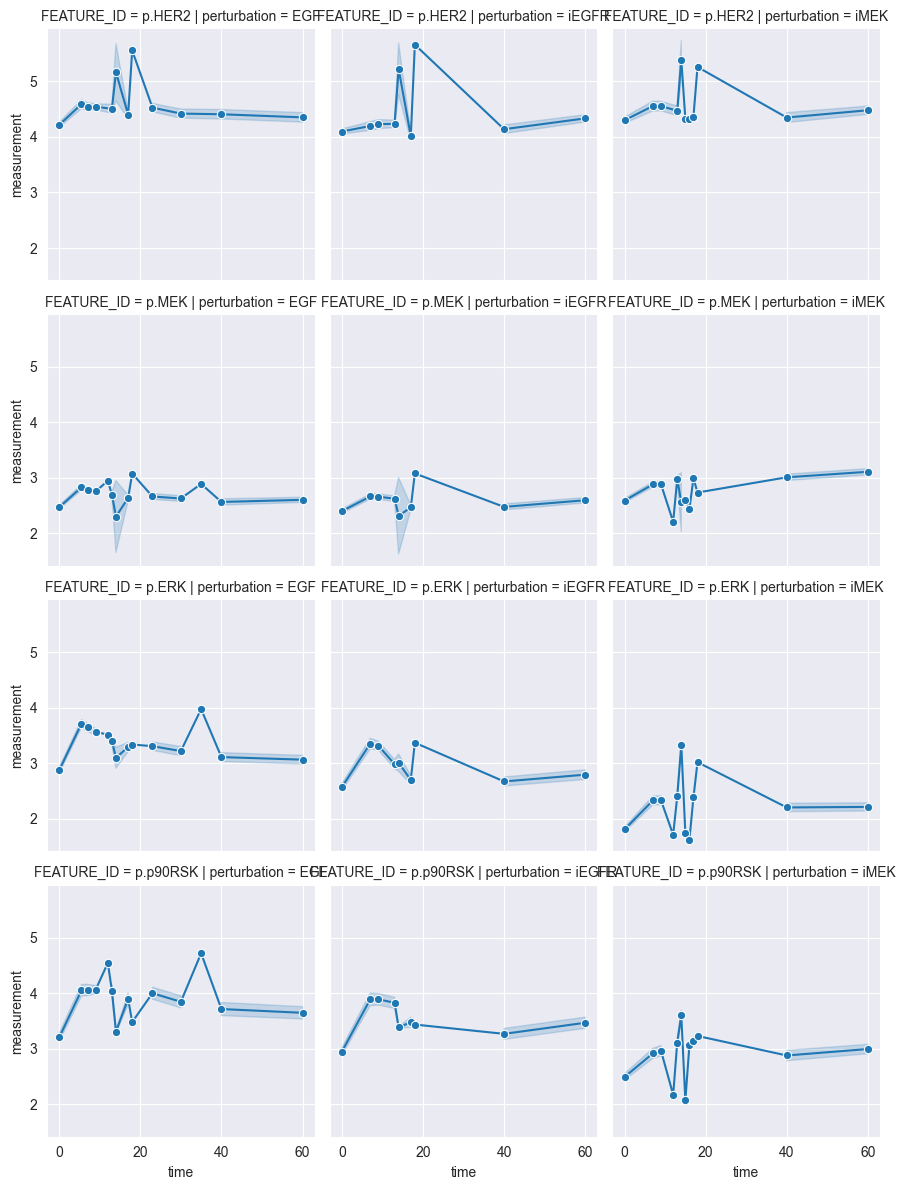

In [1]:
import seaborn as sns
import warnings

from dmm.config_options import Conf
from util import load_petab_base_files

warnings.filterwarnings("ignore")

conf = Conf(
    model = "EGFR_MAPK__logobs_tegfr_aggavg",  # tEGFR model
    data = "dream_cytof",
    n_hidden = 6,
    depth = 0,
    dropout_rate=0.1,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    recon_loss=1e-4,
    n_epoch=500,
    multiheaded=False,
)

petab_base_files = load_petab_base_files(conf)
meas_df = petab_base_files["measurement_table"]

cytof_df = meas_df[meas_df.measurementType == "cytof"]
cytof_df["perturbation"] = cytof_df["simulationConditionId"].apply(lambda x: x.split("__")[1])
cytof_df["cell_line"] = cytof_df["preequilibrationConditionId"]


g = sns.FacetGrid(
    cytof_df[
        (cytof_df.FEATURE_ID.isin(["p.p90RSK", "p.ERK", "p.MEK", "p.HER2"])) &
        (cytof_df.perturbation != "full")
    ],
    col="perturbation",
    row="FEATURE_ID",
    row_order=["p.HER2", "p.MEK", "p.ERK", "p.p90RSK"],
    sharey=True,
)

g.map_dataframe(
    sns.lineplot,
    x="time",
    y="measurement",
    errorbar="se",
    marker='o',
)

# Load parameter deviations for tEGFR model

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from common import evaluations_dir
from training_configuration import PATHWAYS_3

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset", "l1reg_inflater_output", "inflater_output_reg_epoch", "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

cytof_init_par_dev_df = par_dev_df[(par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (par_dev_df.context == "cytof_init")]
mean_cytof_init_par_dev_df = cytof_init_par_dev_df.groupby(["cell_line"])[param_cols].mean()

params_interest = [
    'RPS6KA1_p_S380_ERK__Y204_p_kw',
    'ERK_p_Y204_MEK__S222_p_kw',
    'TOPK_p_Y74_EGFR__Y1173_p_kw',
    'ERBB2_p_Y1248_ERBB2_kw',
    'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
    'ERBB2_p_Y1248_serum_0_kw'
]

# Bin cell-lines based on parameter deviations for top 5 sensitive parameters and plot by group

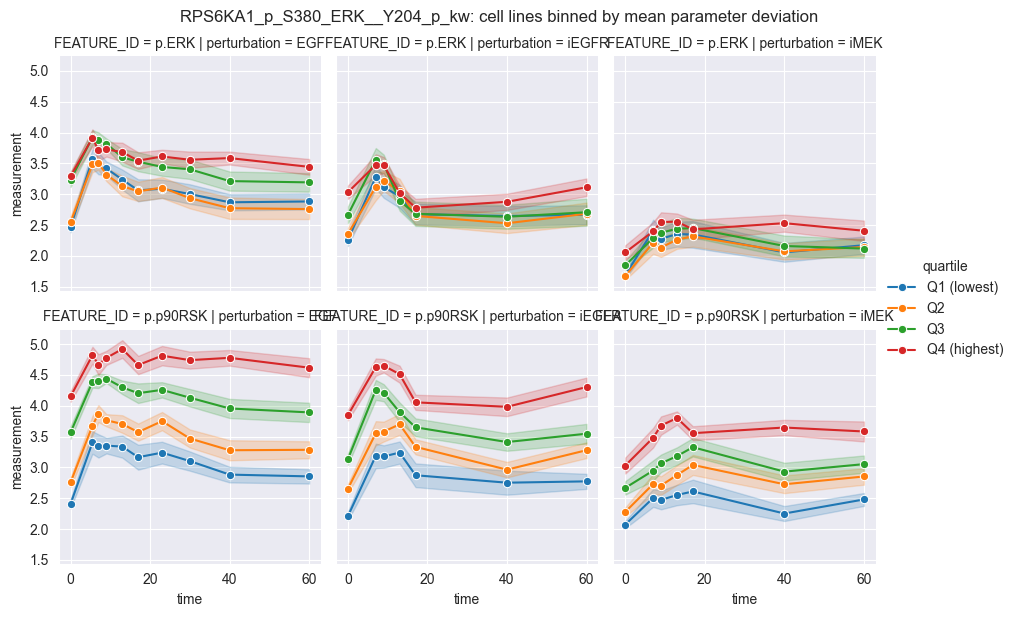

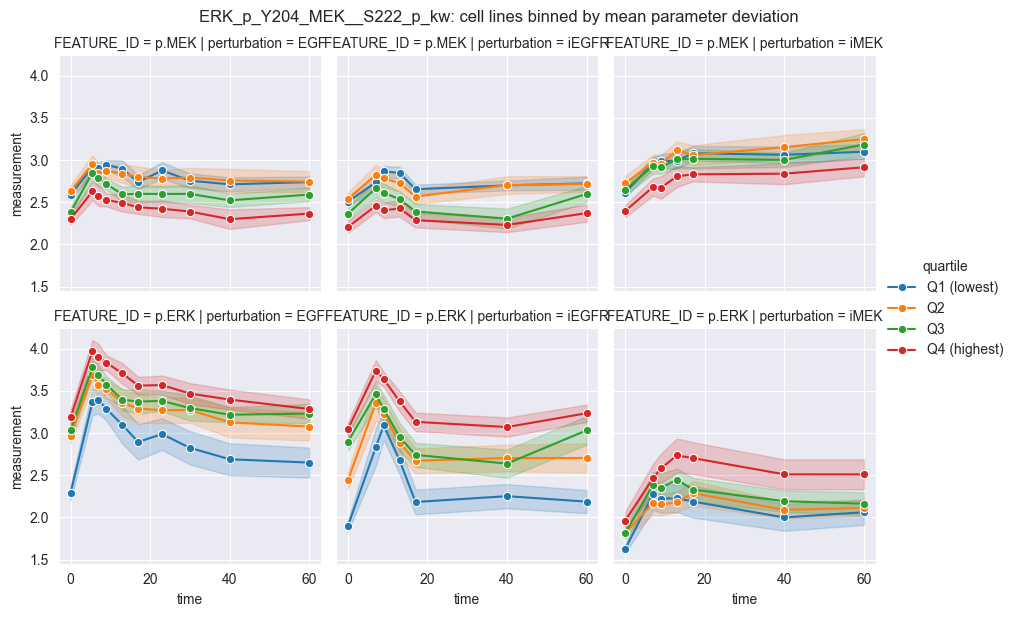

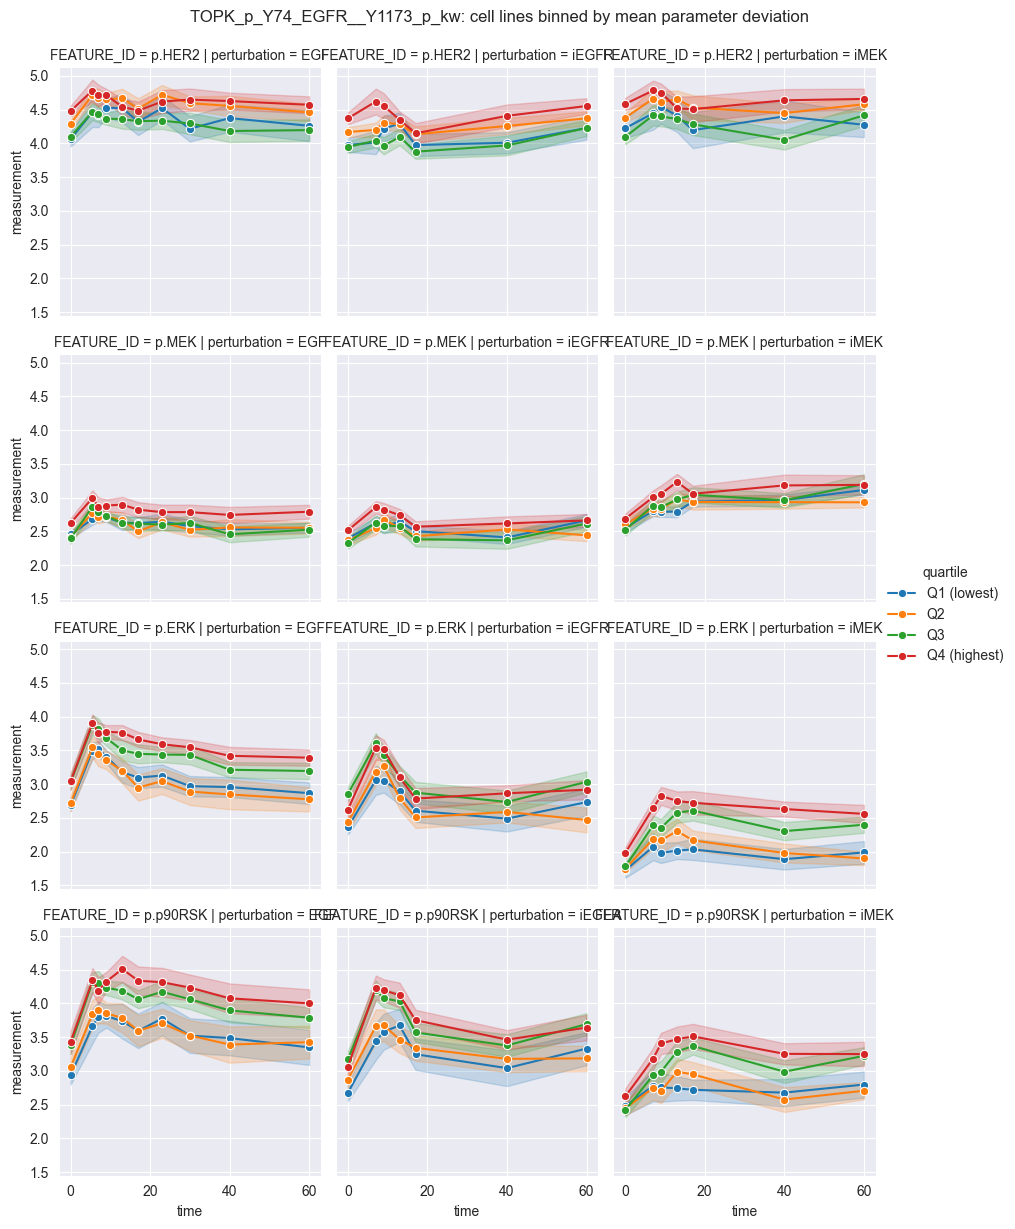

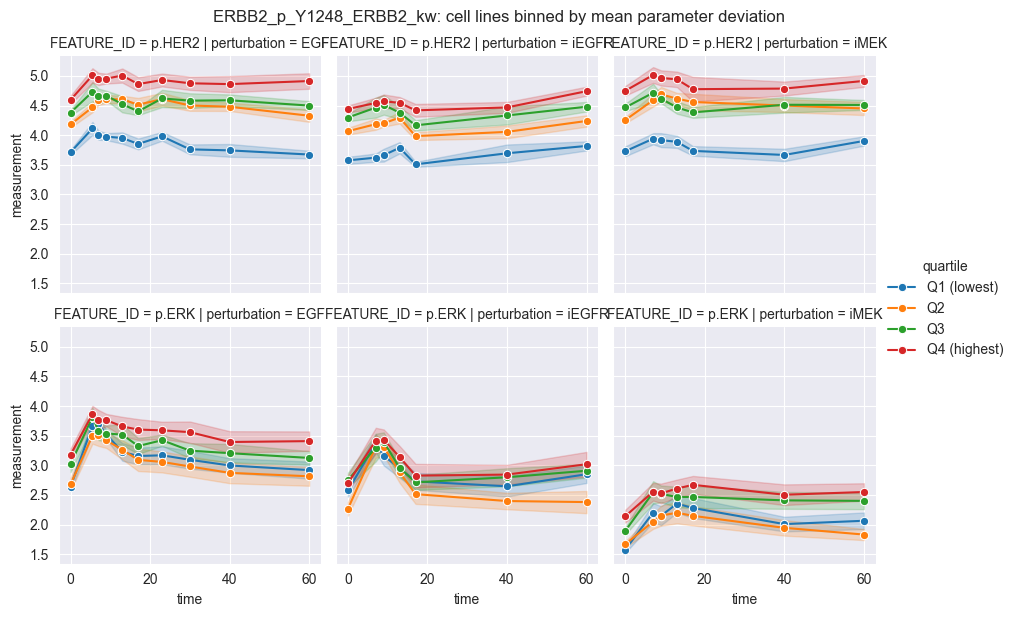

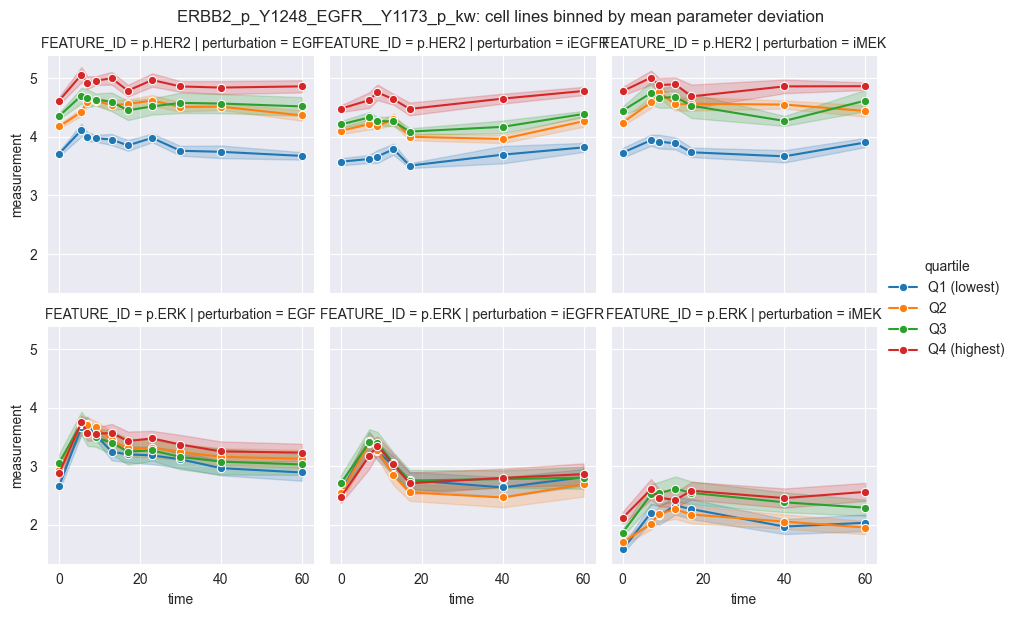

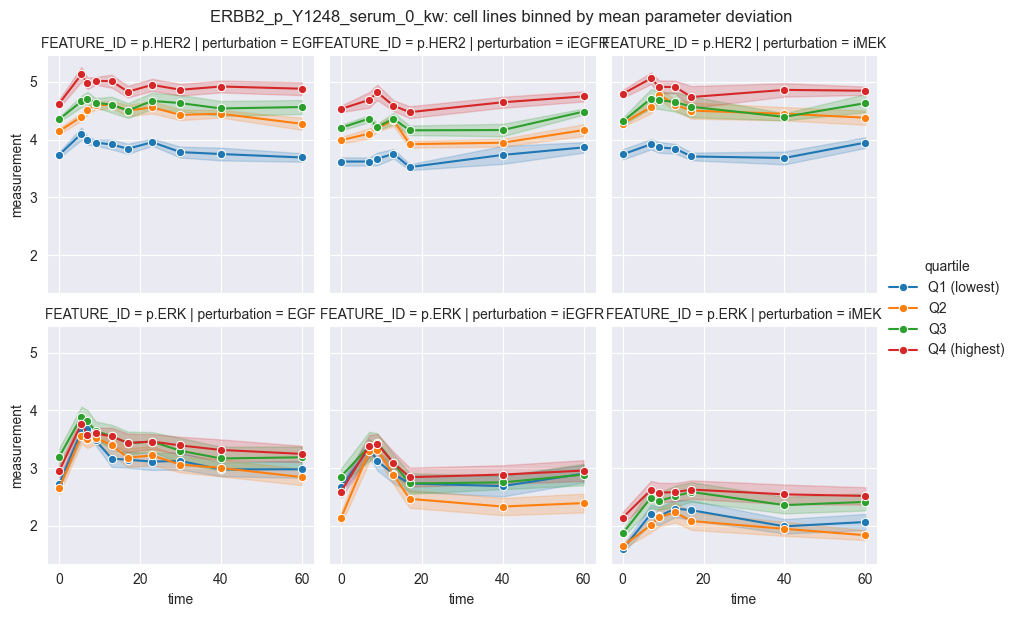

In [3]:
import numpy as np

# 1. Restrict mean deviations to params of interest
mean_cytof_init_par_dev_df_params = mean_cytof_init_par_dev_df[params_interest]

# 2. Map from protein name in param -> FEATURE_ID in cytof_df
protein_to_feature = {
    "ERK": "p.ERK",
    "MEK": "p.MEK",
    "ERBB2": "p.HER2",
    "RPS6KA1": "p.p90RSK",
}

# Base order to preserve a nice consistent ordering
base_row_order = ["p.HER2", "p.MEK", "p.ERK", "p.p90RSK"]


# 2. For each parameter of interest, bin cell lines into quartiles and plot
for param in params_interest:
    # ---- determine which FEATURE_ID to plot for this parameter ----
    features_for_param = [
        feat for prot, feat in protein_to_feature.items()
        if prot in param
    ]

    # if nothing matches, skip this parameter
    if not features_for_param:
        # print(f"Skipping {param}: no matching FEATURE_ID found.")
        # continue
        features_for_param = base_row_order

    if len(features_for_param) == 1:
        features_for_param.append("p.ERK")


    # row_order restricted to the features that are relevant for this parameter
    row_order = [f for f in base_row_order if f in features_for_param]

    # ---- bin cell lines into quartiles for this parameter ----
    med_series = mean_cytof_init_par_dev_df_params[param].dropna()

    quartiles = pd.qcut(
        med_series,
        q=4,
        labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
        duplicates="drop",
    )

    quartile_df = (
        quartiles.rename("quartile")
        .to_frame()
        .reset_index()          # 'cell_line' becomes a column again
        .rename(columns={"index": "cell_line"})  # just to be explicit
    )

    # ---- merge quartiles onto cytof_df ----
    # assumes cytof_df has a 'cell_line' column; if not, construct it from simulationConditionId
    cytof_with_q = cytof_df.merge(quartile_df, on="cell_line", how="left")

    plot_df = cytof_with_q[
        (cytof_with_q.FEATURE_ID.isin(features_for_param)) &
        (cytof_with_q.perturbation != "full") &
        cytof_with_q["quartile"].notna()
    ]

    if plot_df.empty:
        print(f"No data to plot for {param} after filtering.")
        continue

    # Count how many cell lines have data at each (FEATURE_ID, perturbation, time)
    time_counts = (
        plot_df
        .groupby(["FEATURE_ID", "perturbation", "time"])["cell_line"]
        .nunique()
        .reset_index(name="n_cells")
    )

    # Total cell lines per (FEATURE_ID, perturbation)
    total_cells = (
        plot_df
        .groupby(["FEATURE_ID", "perturbation"])["cell_line"]
        .nunique()
        .reset_index(name="total_cells")
    )

    # Compute fraction coverage
    time_cov = time_counts.merge(total_cells, on=["FEATURE_ID", "perturbation"])
    time_cov["frac_cells"] = time_cov["n_cells"] / time_cov["total_cells"]

    # Keep only times with >= 50% of cell lines in that facet
    keep_times = time_cov[time_cov["frac_cells"] >= 0.25][
        ["FEATURE_ID", "perturbation", "time"]
    ]

    # Sanity check
    # print("Skipping timepoints: ", set([t for t in time_cov.time.unique() if t not in keep_times.time.unique()]))

    # Filter plot_df accordingly
    plot_df = plot_df.merge(
        keep_times,
        on=["FEATURE_ID", "perturbation", "time"],
        how="inner",
    )

    if plot_df.empty:
        print(f"No data to plot for {param} after timepoint coverage filtering.")
        continue

    # ---- plot: one FacetGrid per parameter, coloured by quartile ----
    g = sns.FacetGrid(
        plot_df,
        col="perturbation",
        row="FEATURE_ID",
        row_order=row_order,
        sharey=True,
        hue="quartile",
    )

    g.map_dataframe(
        sns.lineplot,
        x="time",
        y="measurement",
        errorbar="se",
        marker="o",
    )

    g.add_legend()
    g.fig.suptitle(
        f"{param}: cell lines binned by mean parameter deviation",
        y=1.02,
    )
    plt.show()